In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
semana_1 = pd.read_csv("../data/staging/operaciones_semana_2025-04-27_2025-05-03.csv")
semana_2 = pd.read_csv("../data/staging/operaciones_semana_2025-05-04_2025-05-10.csv")
semana_3 = pd.read_csv("../data/staging/operaciones_semana_2025-05-11_2025-05-17.csv")
semana_4 = pd.read_csv("../data/staging/operaciones_semana_2025-05-18_2025-05-24.csv")
semana_5 = pd.read_csv("../data/staging/operaciones_semana_2025-05-25_2025-05-31.csv")
semana_6 = pd.read_csv("../data/staging/operaciones_semana_2025-06-01_2025-06-06.csv")

In [3]:
df = pd.concat([semana_1, semana_2, semana_3, semana_4, semana_5, semana_6], ignore_index=True)
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
fechaOperacion,2025-05-03T23:50:33.257,2025-05-03T11:31:36.837,2025-05-03T09:00:36.66,2025-05-03T08:59:09.52,2025-05-02T23:50:47.7,2025-05-02T23:50:40.5,2025-05-02T23:50:36.897,2025-05-02T23:50:33.343,2025-05-02T23:32:16.323,2025-05-02T23:32:12.277
fechaConcertacion,2025-05-03T00:00:00,2025-05-03T00:00:00,2025-04-30T00:00:00,2025-04-30T00:00:00,2025-05-02T00:00:00,2025-05-02T00:00:00,2025-05-02T00:00:00,2025-05-02T00:00:00,2025-05-02T00:00:00,2025-05-02T00:00:00
tipoOperacion,Contrato,Contrato,Contrato,Contrato,Contrato,Contrato,Contrato,Contrato,Contrato,Contrato
tipoModalidad,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa,Compraventa
tipoOiv,Fijar Precio/Mercado Comprador,Precio Hecho,Precio Hecho,Precio Hecho,Fijar Precio/Mercado Comprador,Fijar Precio/Mercado Comprador,Fijar Precio/Mercado Comprador,Fijar Precio/Mercado Comprador,Fijar Precio/Otros,Fijar Precio/Otros
grano,MAIZ,TRIGO PAN,SOJA,SOJA,MAIZ,MAIZ,SOJA,MAIZ,SOJA,SOJA
volumenTN,1000.0,283.31,338.14,295.99,540.0,1000.0,1000.0,360.0,90.0,210.0
condicionCalidad,Cámara,Art. 12,Fábrica,Fábrica,Cámara,Cámara,Fábrica,Cámara,Cámara,Cámara
condicionCalidadAuxiliar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
procedenciaProvincia,CÓRDOBA,BUENOS AIRES,CÓRDOBA,CÓRDOBA,CÓRDOBA,CÓRDOBA,BUENOS AIRES,SANTA FE,SALTA,CÓRDOBA


In [4]:
df['simboloPrecioPorTN'].value_counts()

simboloPrecioPorTN
$      7361
U$S    1354
Name: count, dtype: int64

In [5]:
df.isna().sum()

fechaOperacion                  0
fechaConcertacion               0
tipoOperacion                   0
tipoModalidad                   0
tipoOiv                         0
grano                           0
volumenTN                       3
condicionCalidad                0
condicionCalidadAuxiliar    10866
procedenciaProvincia            0
procedenciaLocalidad            0
simboloPrecioPorTN           2295
precioTN                     2171
lugarEntrega                    0
fechaEntregaDesde               0
fechaEntregaHasta               0
condicionPago                   0
esDestinoFinal                  0
cosecha                        24
numeroOperacionInstancia        0
nroOperacion                    0
esUltimaInstancia               0
dtype: int64

In [6]:
df['tipoOiv'].value_counts() # Agrupar en una sola precio a fijar

tipoOiv
Precio Hecho                      5142
Fijar Precio/Mercado Comprador    2276
Fijar Precio/Otros                2239
Fijar Precio/Prec. Cam.           1132
Fijar Precio/M. T. País            218
Fijar Precio/Fas teórico             2
Fijar Precio/PR R. Conj.             1
Name: count, dtype: int64

In [7]:
df['lugarEntrega'].value_counts()

lugarEntrega
Rosario N/En destino    2354
Rosario S/En destino     953
Zona 13/En destino       681
Zona 9/En destino        663
Zona 8/En destino        632
Zona 6/En destino        594
Zona 14/En destino       478
Zona 11/En destino       454
Zona 18/En destino       368
Zona 5/En destino        359
Cordoba/En destino       313
Zona 7/En destino        266
Zona 15/En destino       251
Zona 12/En destino       235
Zona 15/En origen        207
Cordoba/En origen        168
Zona 16/En origen        166
Quequen/En destino       163
Bs As/En destino         152
B.Blanca/En destino      151
Zona 11/En origen        142
Zona 25/En destino       135
Zona 16/En destino       118
Zona 2/En destino        109
Zona 17/En origen        108
Zona 3/En destino        108
Zona 7/En origen          94
Zona 4/En destino         76
Rosario N/En origen       62
Zona 14/En origen         57
Zona 6/En origen          56
Zona 10/En destino        54
Zona 17/En destino        52
Zona 8/En origen          45
Z

In [8]:
precio_a_fijar = ['Fijar Precio/Mercado Comprador', 'Fijar Precio/Otros', 'Fijar Precio/Prec. Cam.', 'Fijar Precio/M. T. País', 'Fijar Precio/Fas teórico', 'Fijar Precio/PR R. Conj.']

# renombrar valores de tipoOiv a precio a fijar y otros
df['tipoOiv_v2'] = df['tipoOiv'].replace(precio_a_fijar, 'Precio a Fijar')
df['tipoOiv_v2'].value_counts()

tipoOiv_v2
Precio a Fijar    5868
Precio Hecho      5142
Name: count, dtype: int64

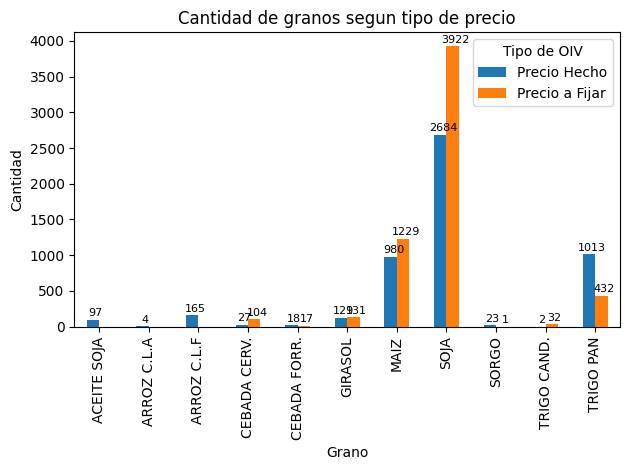

In [ ]:
# grafico de barras de la cantidad de granos segun tipoOiv_v2
ax = df.groupby(['grano', 'tipoOiv_v2']).size().unstack().plot(kind='bar', stacked=False)
plt.title('Cantidad de granos segun tipo de precio')
plt.xlabel('Grano')
plt.ylabel('Cantidad')
plt.legend(title='Tipo de OIV')

# agregar etiquetas con los valores encima de cada barra
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h != 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

El trigo, arroz y aceite soja son los unicos cultivos que se comercian más con precio hecho. 

In [ ]:
df[df['volumenTN'].isna()].T # Estos casos podemos descartarlos

,4291,6672,8968
fechaOperacion,2025-05-15T15:07:32.14,2025-05-22T09:12:03.37,2025-05-29T14:02:17.427
fechaConcertacion,2025-05-15T00:00:00,2025-05-22T00:00:00,2025-05-29T00:00:00
tipoOperacion,Contrato,Contrato,Contrato
tipoModalidad,Compraventa,Compraventa,Compraventa
tipoOiv,Fijar Precio/Otros,Fijar Precio/Otros,Fijar Precio/Otros
grano,MAIZ,MAIZ,MAIZ
volumenTN,NaN,NaN,NaN
condicionCalidad,Cámara,Cámara,Cámara
condicionCalidadAuxiliar,NaN,NaN,NaN
procedenciaProvincia,CÓRDOBA,CÓRDOBA,CÓRDOBA


In [10]:
# Grano por localidad

df_prov_loc = df.groupby(['procedenciaProvincia', 'procedenciaLocalidad', 'grano']).agg({'volumenTN': ['sum', 'mean', 'count']})
df_prov_loc.head(10)

volumenTN               \
                                                             sum         mean   
procedenciaProvincia procedenciaLocalidad grano                                 
BUENOS AIRES         16 DE JULIO          TRIGO CAND.      47.66    47.660000   
                     25 DE MAYO           CEBADA CERV.   1200.00   600.000000   
                                          MAIZ           3577.40   255.528571   
                                          SOJA           2407.90   185.223077   
                                          TRIGO PAN        60.00    60.000000   
                     30 DE AGOSTO         SOJA           1100.00   550.000000   
                     9 DE ABRIL           MAIZ           2000.00  2000.000000   
                     9 DE JULIO           MAIZ           5270.00   585.555556   
                                          SOJA           9360.08   780.006667   
                                          TRIGO PAN      3410.00   162.380952   

                                                              
                                                       count  
procedenciaProvincia procedenciaLocalidad grano               
BUENOS AIRES         16 DE JULIO          TRIGO CAND.      1  
                     25 DE MAYO           CEBADA CERV.     2  
                                          MAIZ            14  
                                          SOJA            13  
                                          TRIGO PAN        1  
                     30 DE AGOSTO         SOJA             2  
                     9 DE ABRIL           MAIZ             1  
                     9 DE JULIO           MAIZ             9  
                                          SOJA            12  
                                          TRIGO PAN       21

In [ ]:
# Volumen por grano
df.groupby('grano').agg({'volumenTN': ['sum', 'mean', 'count']})


volumenTN                  
                     sum        mean count
grano                                     
ACEITE SOJA      4917.10   50.691753    97
ARROZ C.L.A      1472.97  368.242500     4
ARROZ C.L.F     31050.06  188.182182   165
CEBADA CERV.    78230.08  597.176183   131
CEBADA FORR.    10403.93  297.255143    35
GIRASOL         34305.78  131.945308   260
MAIZ           985656.61  446.807167  2206
SOJA          1238394.38  187.465089  6606
SORGO            1555.76   64.823333    24
TRIGO CAND.     14213.95  418.057353    34
TRIGO PAN      248237.23  171.790471  1445